# Outlier Detection, Feature Analysis & Preprocessing

**Objectives**
- Detect outliers using statistical techniques (boxplot, IQR, Z-score)
- Handle rows containing outliers in the relevant columns
- Study the relationships between variables
- Select the variables with the highest variability
- Visualize relationships with graphical tools such as the pairplot
- Apply the appropriate technique to normalize / standardize numerical variables

In [76]:
%load_ext autoreload
%autoreload 2

%pip install scikit-learn


from pathlib import Path
import sys

project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))

import src.data.cleaning as cleaner
import src.data.extracting as extractor
import src.data.charts as Painter
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.options.display.float_format = "{:.2f}".format

diabetes_df = extractor.readData()

display(diabetes_df.head())
diabetes_df = cleaner.KNNImputation(diabetes_df)

intCols = ['Glucose', 'BloodPressure', 'Insulin', 'Age']
diabetes_df[intCols] = diabetes_df[intCols].round().astype('Int64')
display(diabetes_df.head())






The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Note: you may need to restart the kernel to use updated packages.


,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,148.00,72.00,35.00,NaN,33.60,0.63,50
1,85.00,66.00,29.00,NaN,26.60,0.35,31
2,183.00,64.00,NaN,NaN,23.30,0.67,32
3,89.00,66.00,23.00,94.00,28.10,0.17,21
4,137.00,40.00,35.00,168.00,43.10,2.29,33


,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,148,72,35.00,146,33.60,0.63,50
1,85,66,29.00,50,26.60,0.35,31
2,183,64,22.00,281,23.30,0.67,32
3,89,66,23.00,94,28.10,0.17,21
4,137,40,35.00,168,43.10,2.29,33


## 3. Outlier detection

### 3.2 IQR method
Compute Q1, Q3 and IQR for each variable, then the bounds:

- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

Count and list the outliers detected per column.

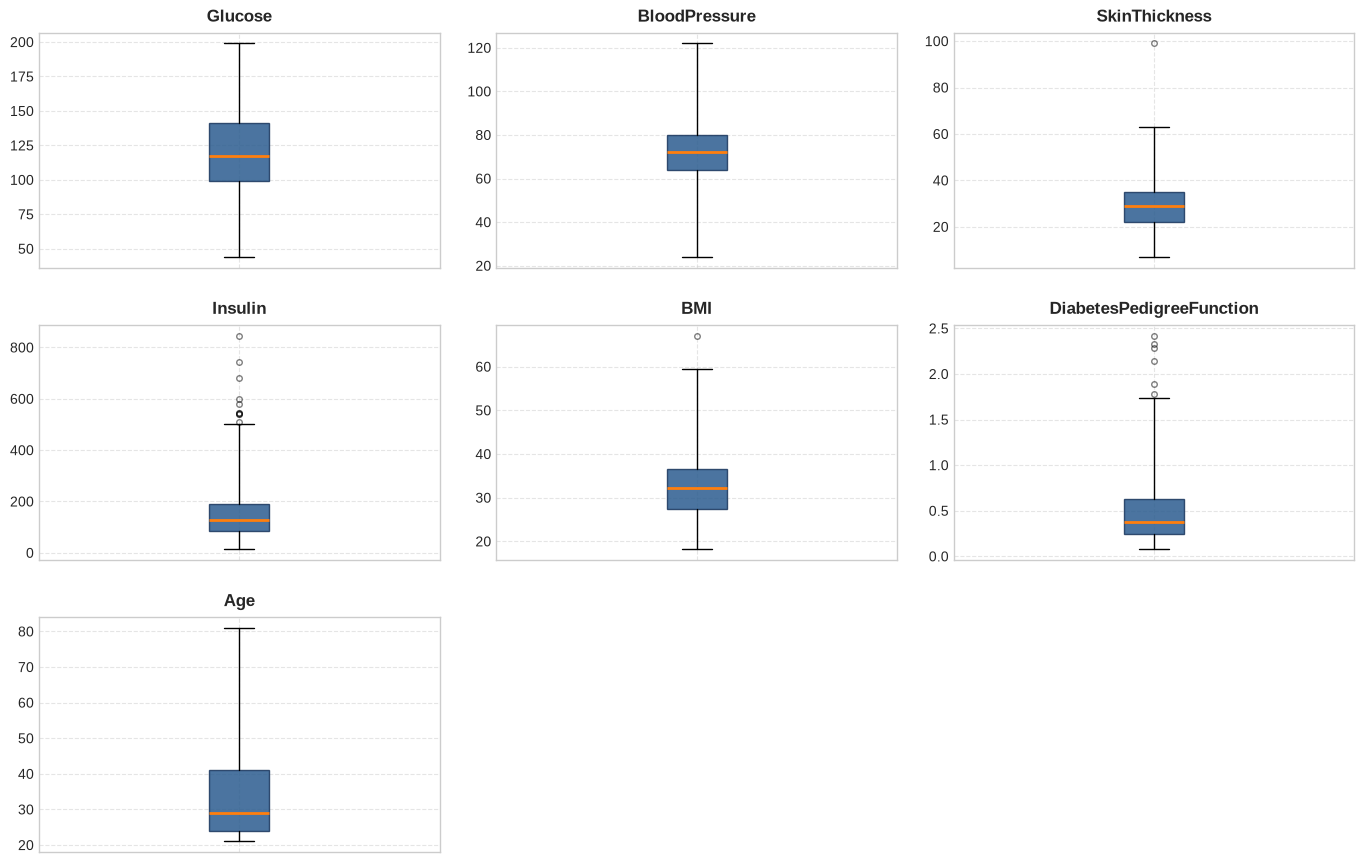

In [77]:
Painter.drawBoxplot(diabetes_df, diabetes_df.columns, 3, 3)

In [78]:
outliers = diabetes_df.copy()
for col in outliers.columns:

    Q1 = diabetes_df[col].quantile(0.25)
    Q3= diabetes_df[col].quantile(0.75)
    IQR = Q3-Q1 

    lowerBound = Q1 - IQR*3
    upperBound  = Q3 + IQR*3

    colOutliers= outliers[(outliers[col]<lowerBound) | (outliers[col]>upperBound)]
    print(f'============{col}===========')
    display(colOutliers)

============Glucose===========


,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age


============BloodPressure===========


,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age


============SkinThickness===========


...

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
177,129,110,46.00,130,67.10,0.32,26


============DiabetesPedigreeFunction===========


,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
4,137,40,35.00,168,43.10,2.29,33
45,180,66,39.00,501,42.00,1.89,25
58,146,82,31.00,148,40.50,1.78,44
228,197,70,39.00,744,36.70,2.33,31
370,173,82,48.00,465,38.40,2.14,25
445,180,78,63.00,14,59.40,2.42,25


============Age===========


,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age


### 3.3 Z-score method
Compute the Z-score of each value and flag observations with |Z| > 3 (or another justified threshold). Count the outliers per column.

In [79]:
threshold = 3
zscore_df = diabetes_df.copy()

for col in diabetes_df.columns:

    colMean = diabetes_df[col].mean()
    standardDeviation = zscore_df[col].std()

    zscore_df[col]= (zscore_df[col] - colMean) / standardDeviation


mask = (zscore_df>threshold) | (zscore_df<-threshold)

outliers = diabetes_df[mask.any(axis=1)]

display(outliers)


,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
4,137,40,35.00,168,43.10,2.29,33
8,197,70,45.00,543,30.50,0.16,53
13,189,60,23.00,846,30.10,0.40,59
18,103,30,38.00,83,43.30,0.18,33
43,171,110,24.00,240,45.40,0.72,54
45,180,66,39.00,501,42.00,1.89,25
57,100,88,60.00,110,46.80,0.96,31
58,146,82,31.00,148,40.50,1.78,44
106,96,122,18.00,96,22.40,0.21,27
111,155,62,26.00,495,34.00,0.54,46


### 3.4 Comparison of the methods
Summary table: number of outliers per column with IQR vs. Z-score. Comment on the differences (Z-score assumes approximately normal data; IQR is more robust to skewness).

## 4. Outlier treatment

### 4.1 Decide which outliers to remove / keep
For each relevant column, justify the decision:
- Are they errors (data entry, measurement) or genuine extreme values?
- Are they meaningful for the business/analysis context?
- What proportion of the data do they represent?

### 4.2 Apply the treatment
Apply the chosen strategy on the relevant columns, e.g.:
- Remove the rows containing outliers
- Cap / winsorize values at the IQR bounds
- Replace with median / mean
- Log or other transformation

In [80]:
cols = ['SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction']

for col in outliers.columns:

    Q1 = diabetes_df[col].quantile(0.25)
    Q3= diabetes_df[col].quantile(0.75)
    IQR = Q3-Q1 

    lowerBound = Q1 - IQR*3
    upperBound  = Q3 + IQR*3

    diabetes_df[col] = diabetes_df[col].clip(lower= lowerBound, upper=upperBound)

### 4.3 Compare before / after
Compare shape of the dataset, descriptive statistics, and boxplots/histograms before and after treatment.

In [81]:
outliers = diabetes_df.copy()
for col in outliers.columns:

    Q1 = diabetes_df[col].quantile(0.25)
    Q3= diabetes_df[col].quantile(0.75)
    IQR = Q3-Q1 

    lowerBound = Q1 - IQR*3
    upperBound  = Q3 + IQR*3

    colOutliers= outliers[(outliers[col]<lowerBound) | (outliers[col]>upperBound)]
    print(f'============{col}===========')
    display(colOutliers)

============Glucose===========


,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age


============BloodPressure===========


,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age


============SkinThickness===========


...

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age


============DiabetesPedigreeFunction===========


,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age


============Age===========


,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age


## 5. Relationship between variables

### 5.1 Correlation matrix
Compute the correlation matrix (Pearson, and optionally Spearman) and display it as a heatmap.

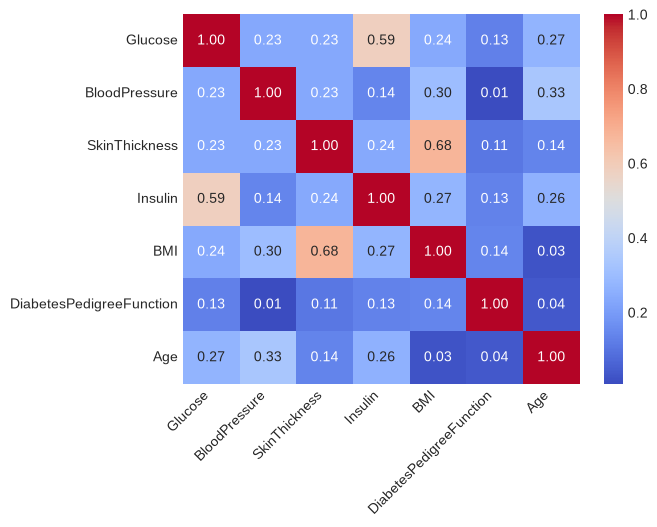

In [82]:
pearson_corr = diabetes_df.corr(method='pearson')
Painter.drawHeatmap(pearson_corr)

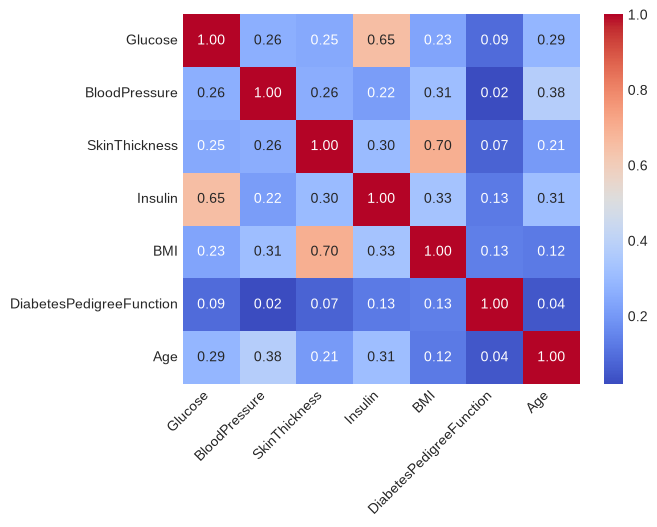

In [83]:
spearman_corr = diabetes_df.corr(method='spearman')
Painter.drawHeatmap(spearman_corr)

### 5.2 Highly correlated pairs
Identify pairs of variables with strong correlation (e.g. |r| > 0.8) and discuss potential redundancy / multicollinearity.

In [84]:
display(diabetes_df)

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,148,72,35.00,146,33.60,0.63,50
1,85,66,29.00,50,26.60,0.35,31
2,183,64,22.00,281,23.30,0.67,32
3,89,66,23.00,94,28.10,0.17,21
4,137,40,35.00,168,43.10,1.77,33
...,...,...,...,...,...,...,...
763,101,76,48.00,180,32.90,0.17,63
764,122,70,27.00,122,36.80,0.34,27
765,121,72,23.00,112,26.20,0.24,30
766,126,60,31.00,127,30.10,0.35,47


### 5.3 Pairplot
Visualize pairwise relationships and distributions with `seaborn.pairplot` (use `hue` for a categorical variable if relevant).

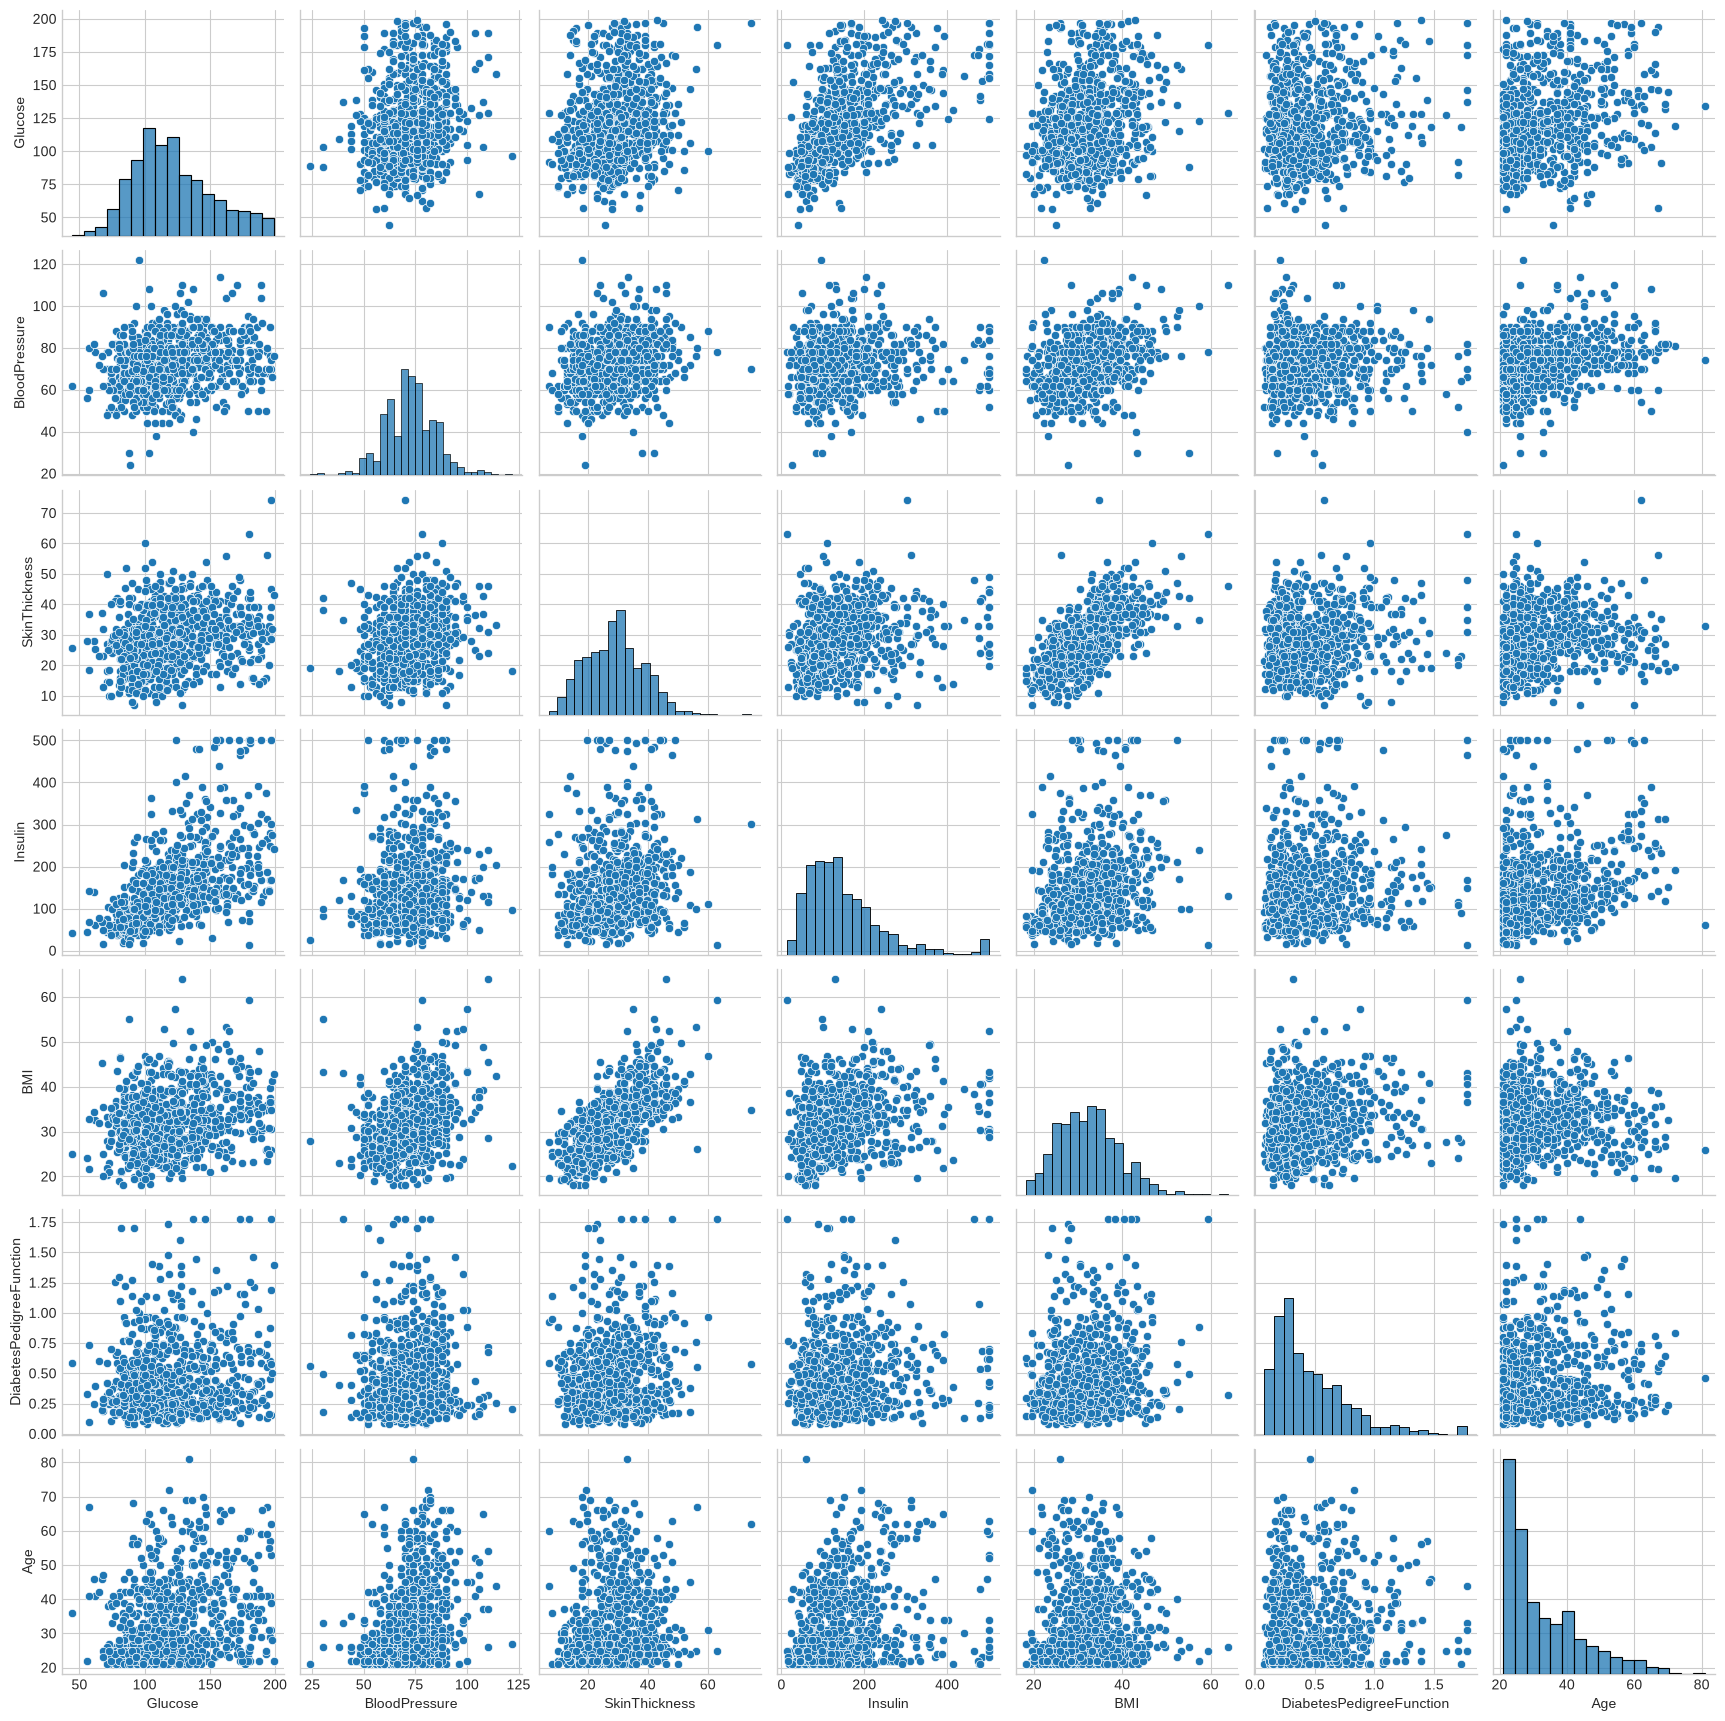

In [85]:
sns.pairplot(diabetes_df)
plt.show()

### 5.4 Interpretation
Summarize the main relationships observed (positive/negative, linear/non-linear, clusters).

## 6. Feature variability

### 6.1 Variance
Compute the variance of each numerical feature.

In [ ]:

numeric_df = diabetes_df.select_dtypes(include="number")

variability = pd.DataFrame({
    "mean": numeric_df.mean(),
    "variance": numeric_df.var(),
    "std": numeric_df.std(),
    "range": numeric_df.max() - numeric_df.min(),
    "IQR": numeric_df.quantile(0.75) - numeric_df.quantile(0.25)
})

print(variability.round(2))

                           mean  variance   std  range    IQR
Glucose                  121.58    930.96 30.51 155.00  42.00
BloodPressure             72.42    150.31 12.26  98.00  16.00
SkinThickness             28.96     92.17  9.60  67.33  13.08
Insulin                  150.46   8706.74 93.31 488.00 104.00
BMI                       32.43     47.45  6.89  45.70   9.10
DiabetesPedigreeFunction   0.47      0.10  0.32   1.70   0.38
Age                       33.24    138.30 11.76  60.00  17.00


### 6.3 Feature selection / justification
Rank the features by variability, select those with the highest variability (e.g. top-k or above a threshold, optionally with `VarianceThreshold`), and justify the choice. Note that variance depends on scale, so consider the coefficient of variation or compute it after scaling.

In [92]:

from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0)

selector.fit(diabetes_df)



print(diabetes_df.columns[selector.get_support()])

print('\n\n')

variability = pd.DataFrame({
    "Variance": diabetes_df.var(),
    "Std": diabetes_df.std(),
    "CV": diabetes_df.std() / diabetes_df.mean()
})

variability = variability.sort_values("CV", ascending=False)

print(variability)




Index(['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
       'DiabetesPedigreeFunction', 'Age'],
      dtype='str')



                          Variance   Std   CV
DiabetesPedigreeFunction      0.10  0.32 0.68
Insulin                    8706.74 93.31 0.62
Age                         138.30 11.76 0.35
SkinThickness                92.17  9.60 0.33
Glucose                     930.96 30.51 0.25
BMI                          47.45  6.89 0.21
BloodPressure               150.31 12.26 0.17


### 6.4 Visualization
Bar chart of the variance / standard deviation per feature, highlighting the selected features.

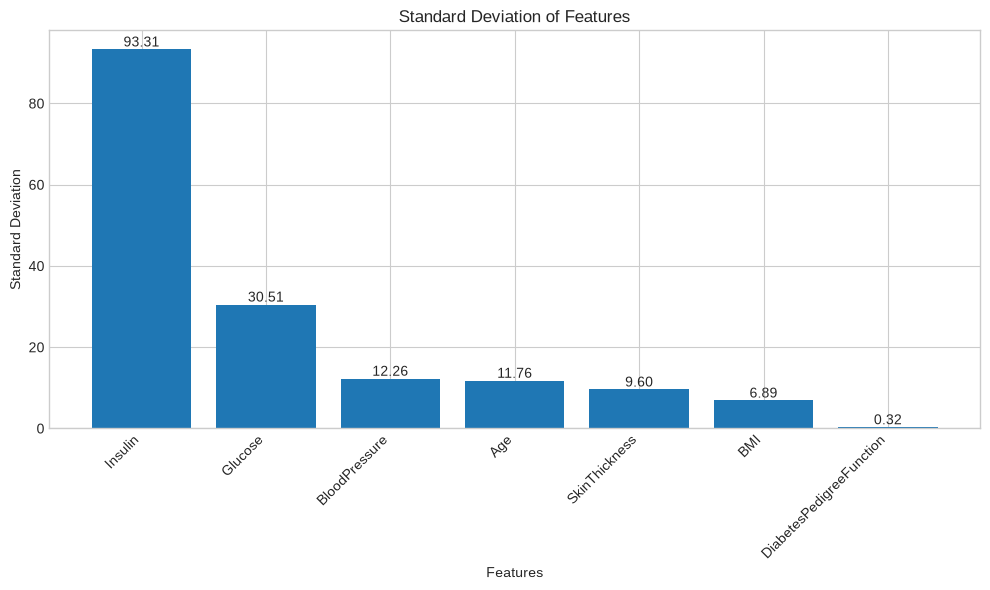

In [91]:
std = diabetes_df.std().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(std.index, std.values)

plt.xlabel("Features")
plt.ylabel("Standard Deviation")
plt.title("Standard Deviation of Features")

plt.xticks(rotation=45, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 7. Feature transformation

### 7.1 Choose the scaling technique
Justify the choice:
- **StandardScaler**: centers to mean 0 and std 1, suited for roughly normal data and distance/gradient-based models.
- **MinMaxScaler**: rescales to [0, 1], suited when a bounded range is needed or the distribution is not normal.

In [96]:
import src.data.processing as Prossessor

diabetes_df_robust = Prossessor.robustScale(diabetes_df)

### 7.2 Apply StandardScaler

In [97]:

diabetes_df_standard = Prossessor.standardize(diabetes_df)

### 7.3 Apply MinMaxScaler

In [98]:

diabetes_df_minmax = Prossessor.normalize(diabetes_df)

### 7.4 Compare distributions
Compare the distributions (histograms/KDE) and descriptive statistics before scaling, after StandardScaler and after MinMaxScaler.

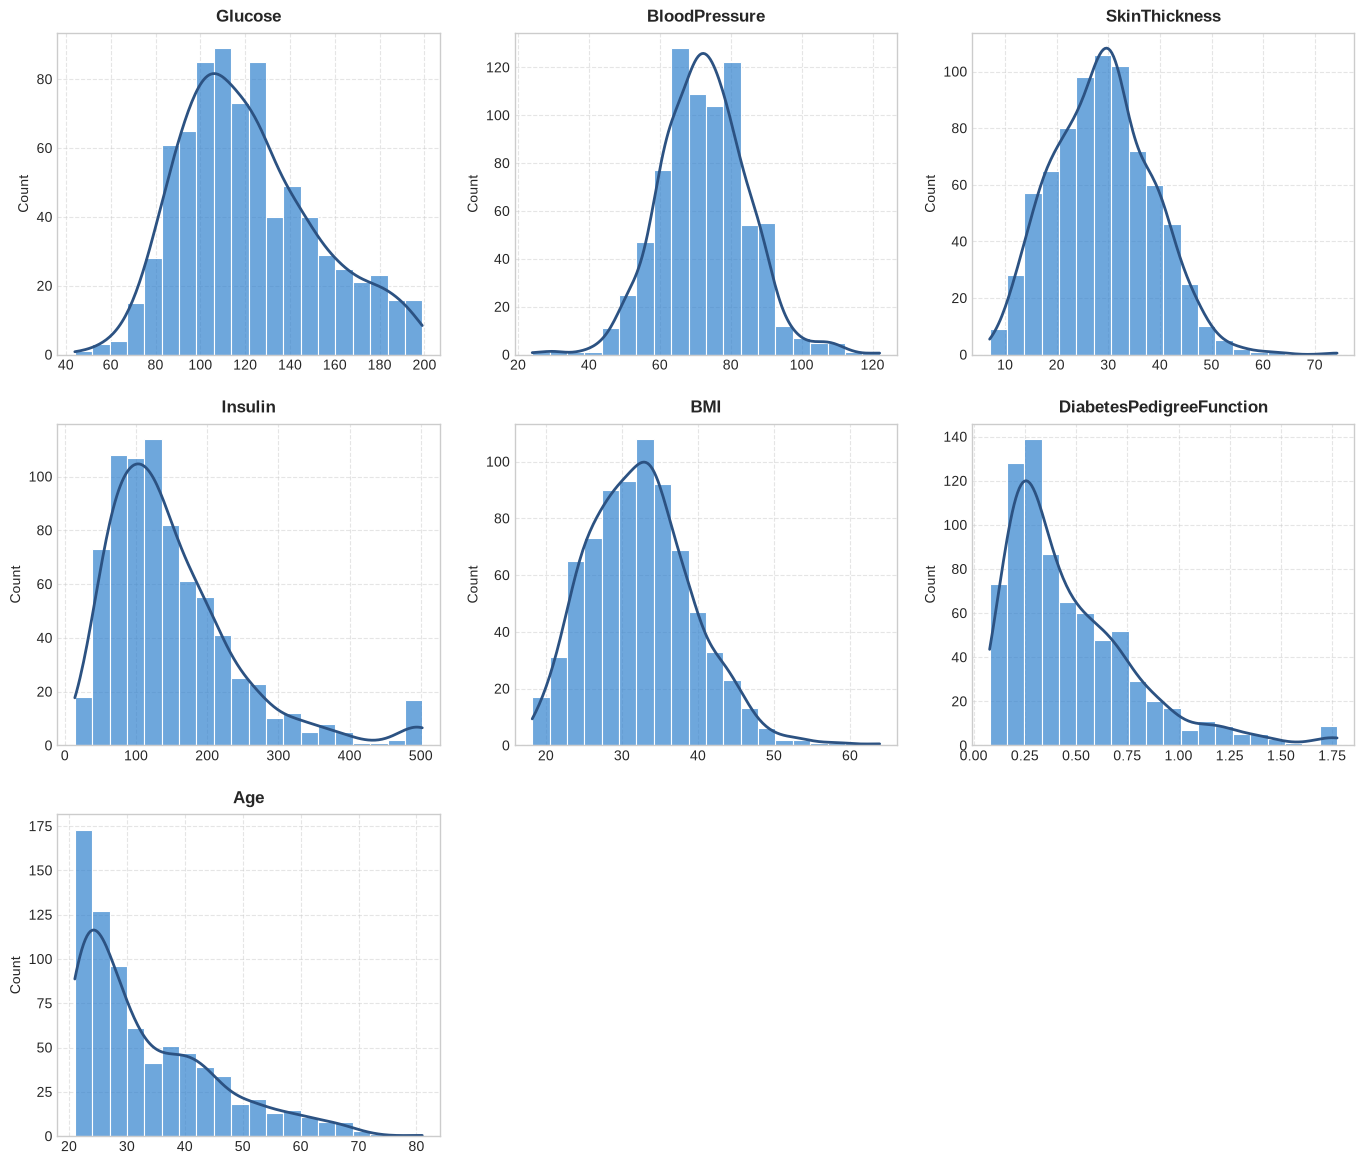

In [94]:
Painter.drawHsitKDE(diabetes_df, diabetes_df.columns)

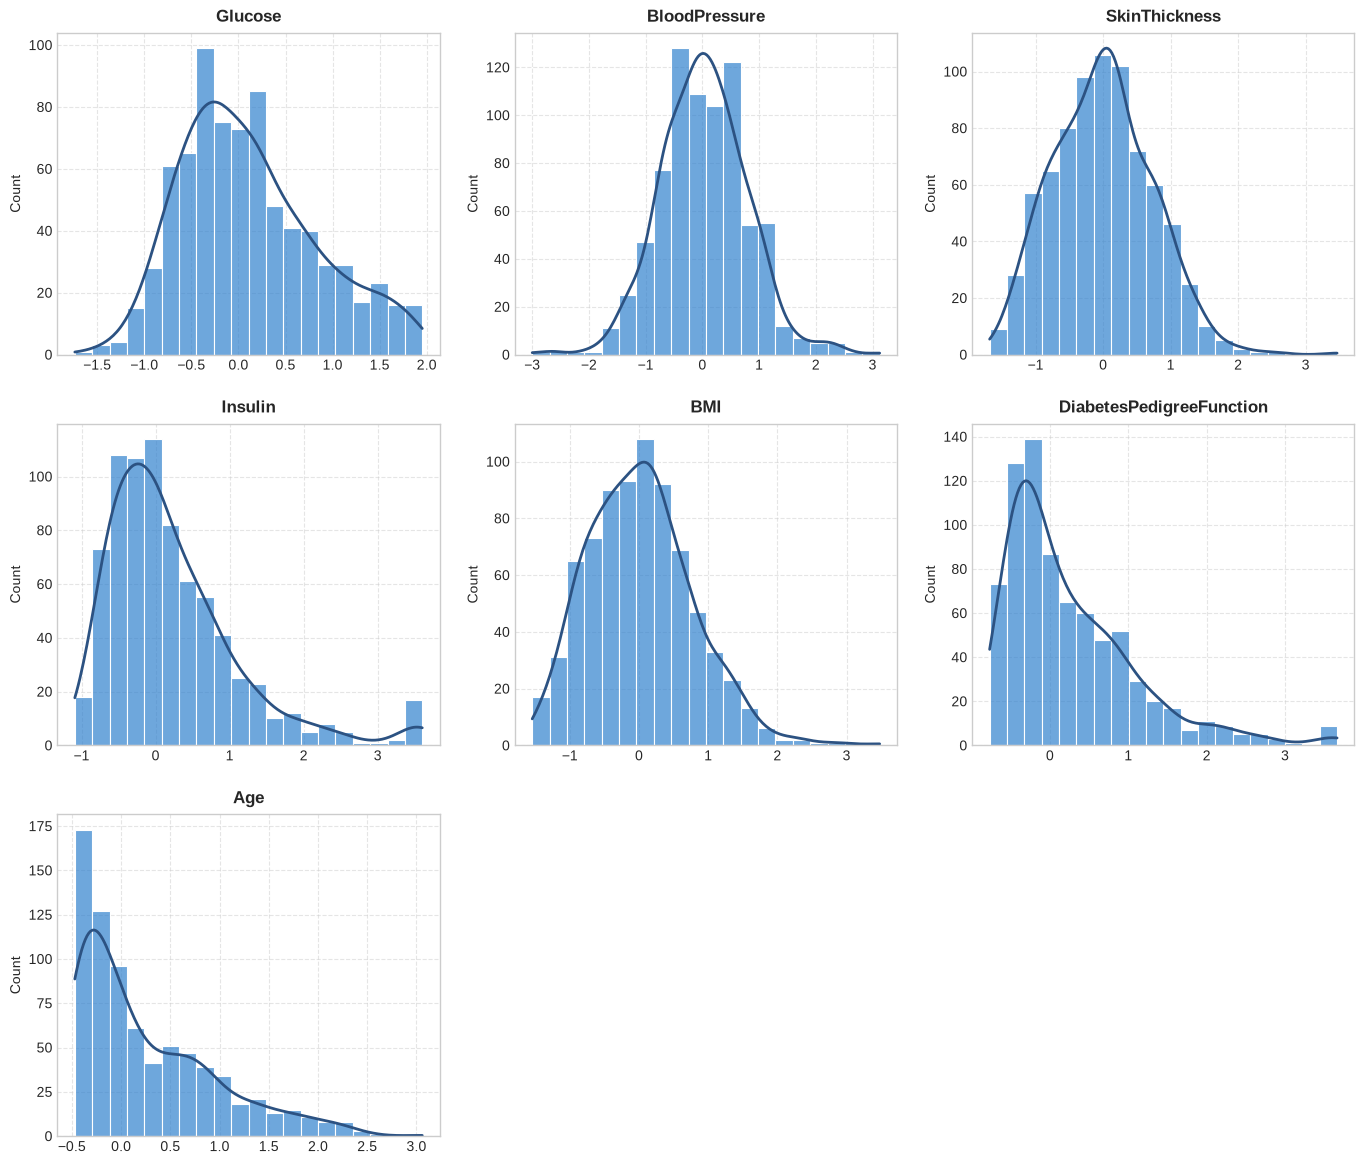

In [99]:
Painter.drawHsitKDE(diabetes_df_robust, diabetes_df_robust.columns)

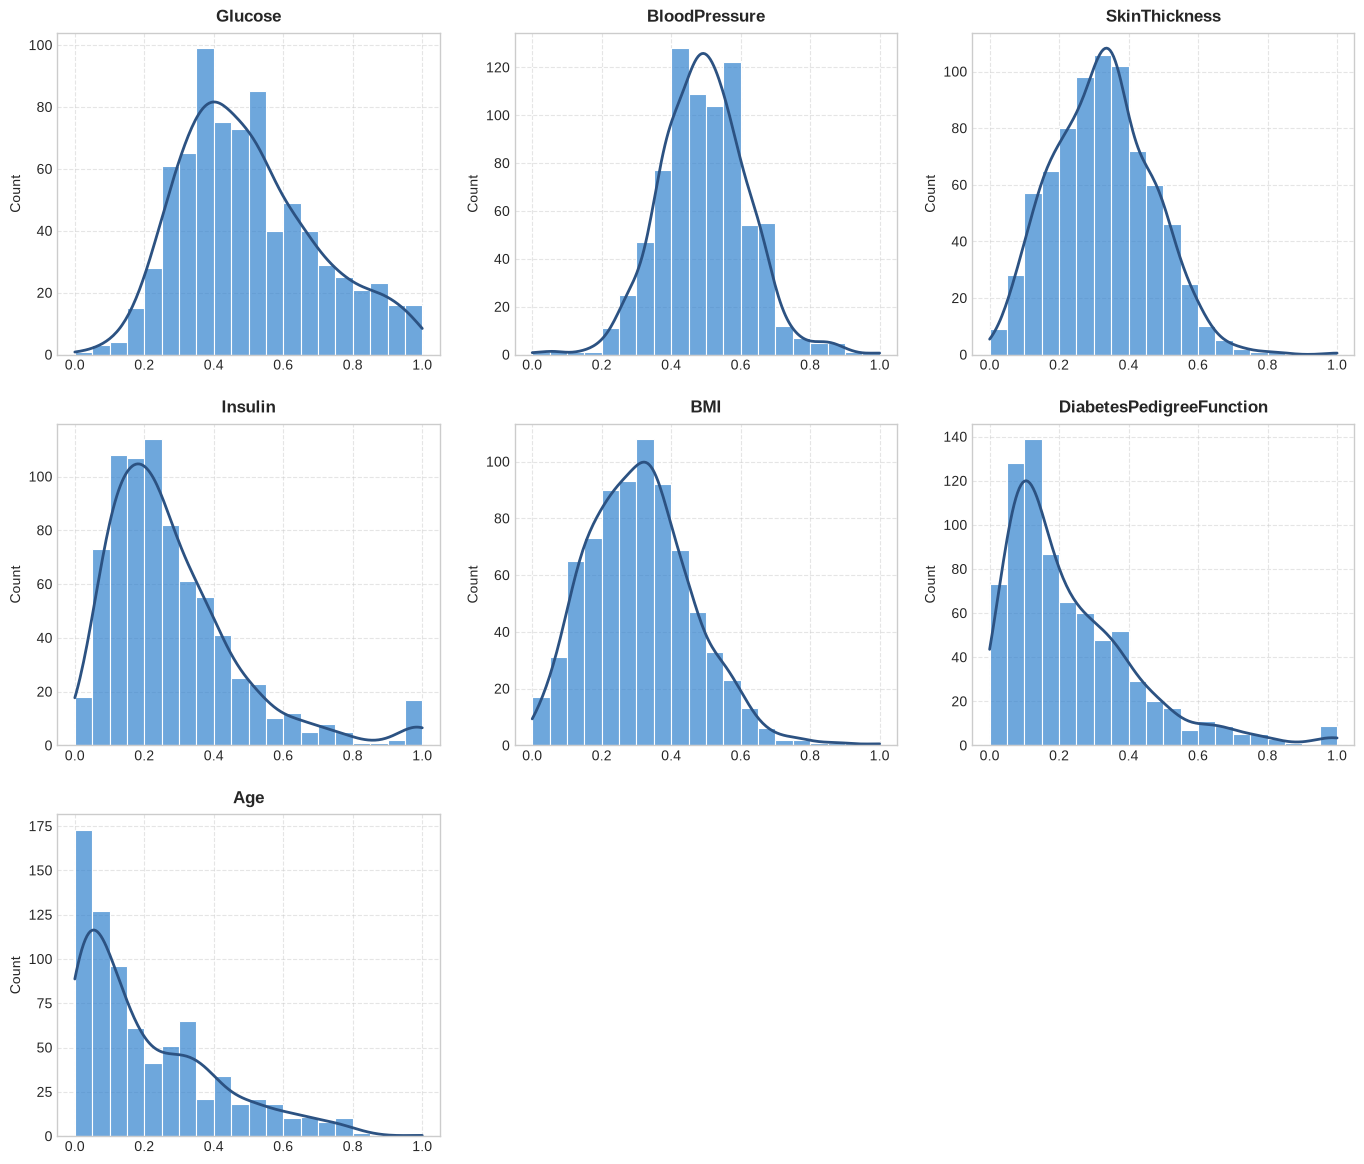

In [100]:
Painter.drawHsitKDE(diabetes_df_minmax, diabetes_df_minmax.columns)

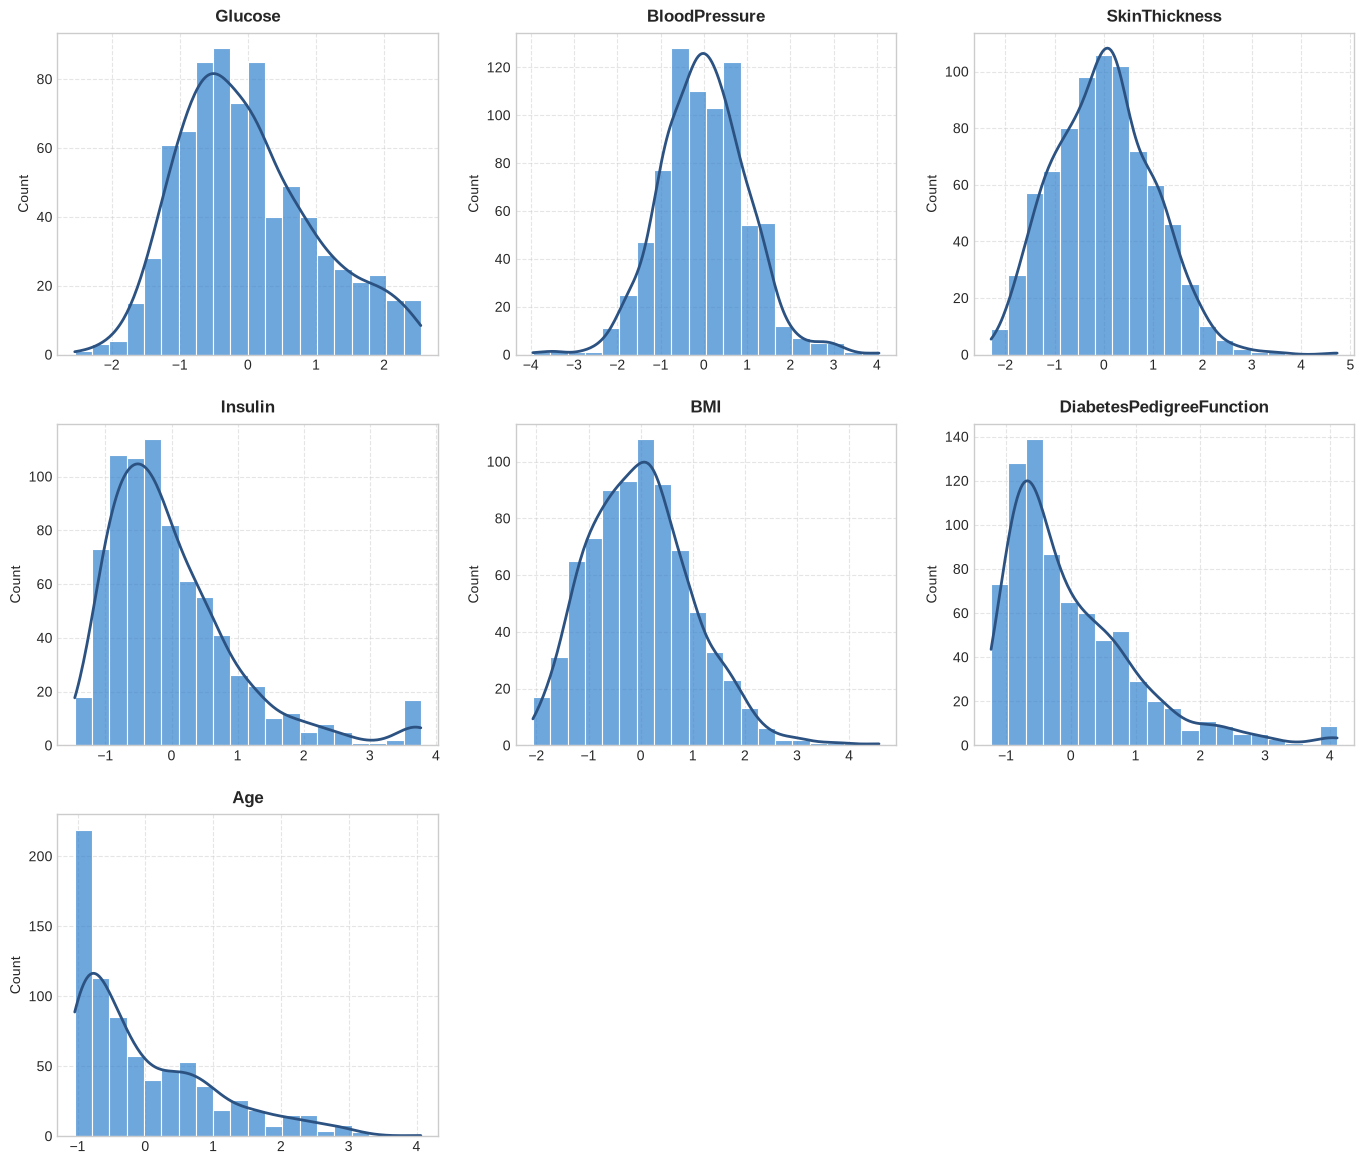

In [101]:
Painter.drawHsitKDE(diabetes_df_standard, diabetes_df_standard.columns)

## 8. Save processed data

### 8.1 Build the final DataFrame
Assemble the processed dataset (selected features, treated outliers, scaled values, plus any non-numerical columns to keep).

### 8.2 Export
Save the processed data to a CSV file (e.g. `processed_data.csv`) and verify by reloading it.

In [102]:
diabetes_df_standard.to_csv("../../data/processed/diabetesDataProcessed.csv")

## 9. Conclusion
Summarize the key findings: outliers detected and how they were handled, main correlations, selected features, and the scaling technique applied.